## Variante Beta del Modelo LSTM

In [5]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split, WeightedRandomSampler
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
import pandas as pd
import numpy as np
import torch.optim as optim
import time
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [11]:
torch.manual_seed(23)
np.random.seed(23)

df = pd.read_csv("C:/Users/irvin/UVG/Octavo_Semestre/Data_Science/PROYECTO2_DS/data/train_clean.csv")
print(df.head())

print("\n CARGADO DE DATOS ")
df = pd.read_csv("C:/Users/irvin/UVG/Octavo_Semestre/Data_Science/PROYECTO2_DS/data/train_clean.csv")
print(f"Dimensiones del dataset: {df.shape}")

# Ver distribución de clases
print("\n Distribución de clases:")
print(df["discourse_effectiveness"].value_counts())

   Unnamed: 0  discourse_id      essay_id discourse_type  \
0           0  0013cc385424  007ACE74B050           Lead   
1           1  9704a709b505  007ACE74B050       Position   
2           2  c22adee811b6  007ACE74B050          Claim   
3           3  a10d361e54e4  007ACE74B050       Evidence   
4           4  db3e453ec4e2  007ACE74B050   Counterclaim   

  discourse_effectiveness                                         text_clean  
0                Adequate  hi isaac going writing face mar natural landfo...  
1                Adequate  perspective think face natural landform dont t...  
2                Adequate  think face natural landform no life mar descov...  
3                Adequate  life mar would know reason think natural landf...  
4                Adequate  people thought face formed alieans thought lif...  

 CARGADO DE DATOS 
Dimensiones del dataset: (36765, 6)

 Distribución de clases:
discourse_effectiveness
Adequate       20977
Effective       9326
Ineffective     6

In [12]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['discourse_effectiveness'])
print(f"\nMapping de clases: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")


Mapping de clases: {'Adequate': np.int64(0), 'Effective': np.int64(1), 'Ineffective': np.int64(2)}


In [13]:
print("\n PREPROCESAMIENTO ")

# Tokenizador
def tokenizer(text):
    text = str(text).lower()

    text = text.replace('<br />', ' ').replace('\n', ' ').replace('\t', ' ')

    tokens = text.split()
    return tokens

# Aplicar tokenización
df['tokens'] = df['text_clean'].apply(tokenizer)

# Construir vocabulario
def build_vocab(token_lists, min_freq=2, max_vocab_size=35000):
    counter = Counter()
    for tokens in token_lists:
        counter.update(tokens)

    # Ordenar por frecuencia y limitar tamaño
    most_common = counter.most_common(max_vocab_size-2)

    vocab = {'<pad>': 0, '<unk>': 1}
    for idx, (word, count) in enumerate(most_common):
        if count >= min_freq:
            vocab[word] = idx + 2

    print(f"Tamaño del vocabulario: {len(vocab)}")
    print(f"Palabras más comunes: {list(vocab.keys())[:10]}")
    return vocab

vocab = build_vocab(df['tokens'])
vocab_size = len(vocab)

# Convertir a índices y aplicar padding con longitud dinámica
def tokens_to_indices(tokens_list, vocab, max_length=200):
    sequences = []
    for tokens in tokens_list:
        indices = [vocab.get(token, vocab['<unk>']) for token in tokens]
        # No truncar demasiado agresivamente
        indices = indices[:max_length]
        sequences.append(torch.tensor(indices, dtype=torch.long))

    padded_sequences = pad_sequence(sequences, batch_first=True, padding_value=vocab['<pad>'])
    return padded_sequences

# Convertir textos a tensores con longitud más generosa
X = tokens_to_indices(df['tokens'], vocab, max_length=200)
y = torch.tensor(df['label'].values, dtype=torch.long)

print(f"Forma de X: {X.shape}")
print(f"Forma de y: {y.shape}")


 PREPROCESAMIENTO 
Tamaño del vocabulario: 11495
Palabras más comunes: ['<pad>', '<unk>', 'student', 'not', 'would', 'people', 'vote', 'school', 'electoral', 'college']
Forma de X: torch.Size([36765, 200])
Forma de y: torch.Size([36765])


In [14]:
print("\n DIVISIÓN DE DATOS CON BALANCEO ")

# División estratificada
train_idx, temp_idx = train_test_split(
    range(len(X)),
    test_size=0.3,
    stratify=y.numpy(),  # Convertir a numpy para stratify
    random_state=42
)
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=y.numpy()[temp_idx],  # Convertir a numpy para stratify
    random_state=42
)

# Crear datasets
train_dataset = TensorDataset(X[train_idx], y[train_idx])
val_dataset = TensorDataset(X[val_idx], y[val_idx])
test_dataset = TensorDataset(X[test_idx], y[test_idx])

print(f"Entrenamiento: {len(train_dataset)} ejemplos")
print(f"Validación: {len(val_dataset)} ejemplos")
print(f"Prueba: {len(test_dataset)} ejemplos")

# Calcular pesos para balancear clases
class_counts = df['discourse_effectiveness'].value_counts().sort_index()
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts)

print(f"\nPesos de clases para balanceo: {class_weights.to_dict()}")

# Weighted Random Sampler para entrenamiento - CORREGIDO
train_labels = y[train_idx].numpy()  # Convertir a numpy array

# Crear un mapeo de índices numéricos a pesos
class_weights_dict = {
    0: class_weights['Adequate'],    # Adequate -> 0
    1: class_weights['Effective'],   # Effective -> 1
    2: class_weights['Ineffective']  # Ineffective -> 2
}

# Asignar pesos usando el mapeo
sample_weights = [class_weights_dict[label] for label in train_labels]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)



 DIVISIÓN DE DATOS CON BALANCEO 
Entrenamiento: 25735 ejemplos
Validación: 5515 ejemplos
Prueba: 5515 ejemplos

Pesos de clases para balanceo: {'Adequate': 0.46185738273337573, 'Effective': 1.0388572075485765, 'Ineffective': 1.4992854097180477}


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
import numpy as np
import time, os
from collections import Counter
try:
    from tqdm.auto import tqdm
except:
    tqdm = lambda x: x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# parámetros 
IS_CPU = device.type == "cpu"
BATCH_SIZE = 32 if IS_CPU else 64
EMBED_DIM = 256
HIDDEN_SIZE = 320
NUM_LAYERS = 2
DROPOUT = 0.35
BIDIRECTIONAL = True
EPOCHS = 23
PATIENCE = 4
GRAD_CLIP = 5.0

pad_idx = vocab.get('<pad>', 0)
NUM_CLASSES = len(label_encoder.classes_)
print(f"Vocab size: {vocab_size}  Pad idx: {pad_idx}  Num classes: {NUM_CLASSES}")

# --- collate: soporta (seq, label) o (seq, label, aux_dict) ---
def collate_batch(batch):
    seqs = torch.stack([item[0] for item in batch])    # (B, L)
    labels = torch.tensor([int(item[1]) for item in batch], dtype=torch.long)
    lengths = (seqs != pad_idx).sum(dim=1)

    # handle optional aux
    aux_list = None
    if len(batch[0]) >= 3:
        # assume aux is dict; build matrix of floats
        try:
            aux_keys = list(batch[0][2].keys())
            aux_arr = np.stack([np.array([float(x[k]) for k in aux_keys]) for _, _, x in batch])
            aux_list = torch.tensor(aux_arr, dtype=torch.float)
        except Exception as e:
            aux_list = None

    # move to device
    seqs = seqs.to(device)
    lengths = lengths.to(device)
    labels = labels.to(device)
    if aux_list is not None:
        aux_list = aux_list.to(device)
        return seqs, lengths, labels, aux_list
    else:
        return seqs, lengths, labels

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=(sampler if 'sampler' in globals() and sampler is not None else None),
                          shuffle=(False if 'sampler' in globals() and sampler is not None else True),
                          collate_fn=collate_batch, drop_last=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE*2, shuffle=False, collate_fn=collate_batch)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE*2, shuffle=False, collate_fn=collate_batch)
print("Loaders: ", len(train_loader), len(val_loader), len(test_loader))

def compute_class_weights(dataset):
    counts = Counter()
    for item in dataset:
        lab = int(item[1])
        counts[lab] += 1
    freqs = [counts[i] for i in range(NUM_CLASSES)]
    total = sum(freqs)
    # weight = total / (num_classes * freq)  (inversa proporcional)
    weights = [total / (NUM_CLASSES * (f if f>0 else 1)) for f in freqs]
    return torch.tensor(weights, dtype=torch.float).to(device)

try:
    class_weights = compute_class_weights(train_dataset)
    print("Class weights:", class_weights.cpu().numpy())
    criterion = nn.CrossEntropyLoss(weight=class_weights)
except Exception as e:
    print("No se pudieron calcular pesos de clase, uso CrossEntropyLoss simple.", str(e))
    criterion = nn.CrossEntropyLoss()

# --- Atención de pooling sobre salidas LSTM ---
class AttentionPooling(nn.Module):
    def __init__(self, hidden_dim, attn_dim=128):
        super().__init__()
        self.linear = nn.Linear(hidden_dim, attn_dim, bias=True)
        self.v = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, h, mask):
        # h: (B, L, H)
        # mask: (B, L)  True for valid tokens
        # energy: (B, L, attn_dim)
        energy = torch.tanh(self.linear(h))          # (B,L,A)
        scores = self.v(energy).squeeze(-1)         # (B, L)
        scores = scores.masked_fill(~mask, float('-1e9'))
        alpha = torch.softmax(scores, dim=1)        # (B,L)
        context = torch.bmm(alpha.unsqueeze(1), h).squeeze(1)  # (B, H)
        return context, alpha

# --- Modelo: Embedding -> BiLSTM -> AttentionPooling -> FC (+ opcional aux features) ---
class LSTMWithAttention(nn.Module):
    def __init__(self, vocab_size, embed_dim=EMBED_DIM, hidden_size=HIDDEN_SIZE,
                 num_layers=NUM_LAYERS, num_classes=NUM_CLASSES, dropout=DROPOUT,
                 bidirectional=BIDIRECTIONAL, padding_idx=0, use_aux=False, aux_dim=0, attn_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)
        try:
            if 'pretrained_embeddings' in globals():
                with torch.no_grad():
                    emb_tensor = torch.tensor(pretrained_embeddings, dtype=torch.float)
                    if emb_tensor.shape[0] == vocab_size and emb_tensor.shape[1] == embed_dim:
                        self.embedding.weight.data.copy_(emb_tensor)
                        print("Loaded pretrained embeddings into embedding layer.")
        except Exception:
            pass

        self.dropout_in = nn.Dropout(dropout*0.5)
        self.lstm = nn.LSTM(embed_dim, hidden_size, num_layers=num_layers, batch_first=True,
                            bidirectional=bidirectional, dropout=dropout if num_layers>1 else 0.0)
        factor = 2 if bidirectional else 1
        self.attention = AttentionPooling(hidden_dim=hidden_size*factor, attn_dim=attn_dim)
        self.use_aux = use_aux
        fc_input = hidden_size*factor + (aux_dim if use_aux else 0)
        self.fc = nn.Sequential(
            nn.Linear(fc_input, fc_input//2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fc_input//2, num_classes)
        )

    def forward(self, x, lengths, aux=None):
        # x: (B, L)
        mask = (x != pad_idx)  # (B, L) boolean
        emb = self.embedding(x)        # (B, L, E)
        emb = self.dropout_in(emb)

        # pack
        lengths_cpu = lengths.cpu()
        packed = pack_padded_sequence(emb, lengths_cpu, batch_first=True, enforce_sorted=False)
        packed_out, _ = self.lstm(packed)
        out_unpacked, _ = pad_packed_sequence(packed_out, batch_first=True, total_length=x.size(1))  # (B,L,H)

        # Attention pooling
        context, attn_weights = self.attention(out_unpacked, mask)  # (B, H)

        if self.use_aux and aux is not None:
            context = torch.cat([context, aux], dim=1)

        logits = self.fc(context)  # (B, num_classes)
        return logits, attn_weights

# --- instancia del modelo
aux_dim = 0
it = iter(train_loader)
sample = next(it)

has_aux = (len(sample) == 4)
if has_aux:
    aux_dim = sample[3].shape[1]
print("Aux features present:", has_aux, " aux_dim=", aux_dim)
# create model
model = LSTMWithAttention(vocab_size=vocab_size, embed_dim=EMBED_DIM, hidden_size=HIDDEN_SIZE,
                          num_layers=NUM_LAYERS, num_classes=NUM_CLASSES, dropout=DROPOUT,
                          bidirectional=BIDIRECTIONAL, padding_idx=pad_idx, use_aux=has_aux, aux_dim=aux_dim).to(device)
print(model)

# --- optimizer, scheduler, etc. ---
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
# gradient accumulation if CPU or low VRAM (helps emulate larger batches)
GRAD_ACCUM = 1 if not IS_CPU else 2

# --- util evaluación ---
def evaluate_full(model, dataloader):
    model.eval()
    losses = []
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in dataloader:
            if has_aux:
                seqs, lengths, labels, aux = batch
                logits, attn = model(seqs, lengths, aux)
            else:
                seqs, lengths, labels = batch
                logits, attn = model(seqs, lengths, None)
            loss = criterion(logits, labels)
            losses.append(loss.item() * seqs.size(0))
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.cpu().numpy().tolist())
    avg_loss = sum(losses) / len(dataloader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, acc, macro_f1, all_labels, all_preds

# --- entrenamiento con early stopping y checkpoint ---
best_val_loss = float("inf")
no_improve = 0
best_path = "./lstm_attn_best.pt"
os.makedirs(os.path.dirname(best_path) or ".", exist_ok=True)
start_time = time.time()

for epoch in range(1, EPOCHS+1):
    model.train()
    running_loss = 0.0
    nbatch = 0
    optimizer.zero_grad()
    loop = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}")
    for i, batch in enumerate(loop):
        if has_aux:
            seqs, lengths, labels, aux = batch
            logits, _ = model(seqs, lengths, aux)
        else:
            seqs, lengths, labels = batch
            logits, _ = model(seqs, lengths, None)

        loss = criterion(logits, labels) / GRAD_ACCUM
        loss.backward()
        running_loss += loss.item() * GRAD_ACCUM
        nbatch += 1

        if (i+1) % GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
            optimizer.step()
            optimizer.zero_grad()

    train_loss = running_loss / max(1, nbatch)
    val_loss, val_acc, val_f1, _, _ = evaluate_full(model, val_loader)
    scheduler.step(val_loss)
    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_f1={val_f1:.4f}")

    # checkpoint
    if val_loss + 1e-8 < best_val_loss:
        best_val_loss = val_loss
        no_improve = 0
        torch.save({"model_state": model.state_dict(),
                    "vocab": vocab,
                    "label_classes": list(label_encoder.classes_),
                    "epoch": epoch}, best_path)
        print("  -> Mejor modelo guardado.")
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"Early stopping tras {PATIENCE} épocas sin mejora.")
            break

total_min = (time.time() - start_time) / 60.0
print(f"Entrenamiento completado en {total_min:.2f} minutos.")

# --- evaluación final con el mejor checkpoint ---
if os.path.exists(best_path):
    ckpt = torch.load(best_path, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    test_loss, test_acc, test_f1, y_true, y_pred = evaluate_full(model, test_loader)
    print("\n== RESULTADOS FINALES (test) ==")
    print(f"Test loss: {test_loss:.4f}  Test acc: {test_acc:.4f}  Test macro-F1: {test_f1:.4f}\n")
    print("Classification report:")
    print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))
    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))
else:
    print("No checkpoint encontrado para evaluación final.")


C:\Users\irvin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu
Vocab size: 11495  Pad idx: 0  Num classes: 3
Loaders:  805 87 87
Class weights: [0.584196  1.314083  1.8966025]
Aux features present: False  aux_dim= 0
LSTMWithAttention(
  (embedding): Embedding(11495, 256, padding_idx=0)
  (dropout_in): Dropout(p=0.175, inplace=False)
  (lstm): LSTM(256, 320, num_layers=2, batch_first=True, dropout=0.35, bidirectional=True)
  (attention): AttentionPooling(
    (linear): Linear(in_features=640, out_features=128, bias=True)
    (v): Linear(in_features=128, out_features=1, bias=False)
  )
  (fc): Sequential(
    (0): Linear(in_features=640, out_features=320, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.35, inplace=False)
    (3): Linear(in_features=320, out_features=3, bias=True)
  )
)


Epoch 1/23: 100%|██████████| 805/805 [16:23<00:00,  1.22s/it]


Epoch 01 | train_loss=0.7998 val_loss=1.0112 val_acc=0.3579 val_f1=0.3486
  -> Mejor modelo guardado.


Epoch 2/23: 100%|██████████| 805/805 [13:01<00:00,  1.03it/s]


...

Epoch 03 | train_loss=0.5501 val_loss=1.1218 val_acc=0.3985 val_f1=0.3969


Epoch 4/23: 100%|██████████| 805/805 [13:32<00:00,  1.01s/it]


Epoch 04 | train_loss=0.4541 val_loss=1.2071 val_acc=0.4399 val_f1=0.4433


Epoch 5/23: 100%|██████████| 805/805 [13:23<00:00,  1.00it/s]


Epoch 05 | train_loss=0.3514 val_loss=1.3420 val_acc=0.5044 val_f1=0.4950
Early stopping tras 4 épocas sin mejora.
Entrenamiento completado en 71.88 minutos.

== RESULTADOS FINALES (test) ==
Test loss: 1.0199  Test acc: 0.3657  Test macro-F1: 0.3568

Classification report:
              precision    recall  f1-score   support

    Adequate       0.81      0.06      0.11      3147
   Effective       0.45      0.76      0.57      1399
 Ineffective       0.26      0.78      0.39       969

    accuracy                           0.37      5515
   macro avg       0.51      0.54      0.36      5515
weighted avg       0.62      0.37      0.28      5515

Confusion matrix:
[[ 190 1111 1846]
 [  19 1070  310]
 [  25  187  757]]


Se configuró un modelo *LSTM bidireccional con atención* utilizando un tamaño de embedding de *256*, una dimensión oculta de *320*, *2 capas* recurrentes, *dropout de 0.35* y un mecanismo de *attention pooling* con 128 unidades. El modelo fue entrenado durante un máximo de 23 épocas con *early stopping* tras 4 sin mejora, empleando *AdamW* como optimizador y pesos balanceados para las clases. Tras el entrenamiento, se obtuvo una *pérdida de prueba de 1.02*, *precisión global del 36.6 %* y un *macro-F1 de 0.36*, evidenciando un desempeño moderado con mejor rendimiento en la clase *Effective* y mayor confusión en la clase *Adequate*, lo que sugiere que el modelo captura parcialmente las relaciones contextuales, pero aún requiere refinamiento en la separación entre categorías.


Device: cpu
Pad idx: 0
Número de clases detectadas: 3
Total de muestras: 5515

Accuracy: 0.2756
Macro-F1: 0.2345


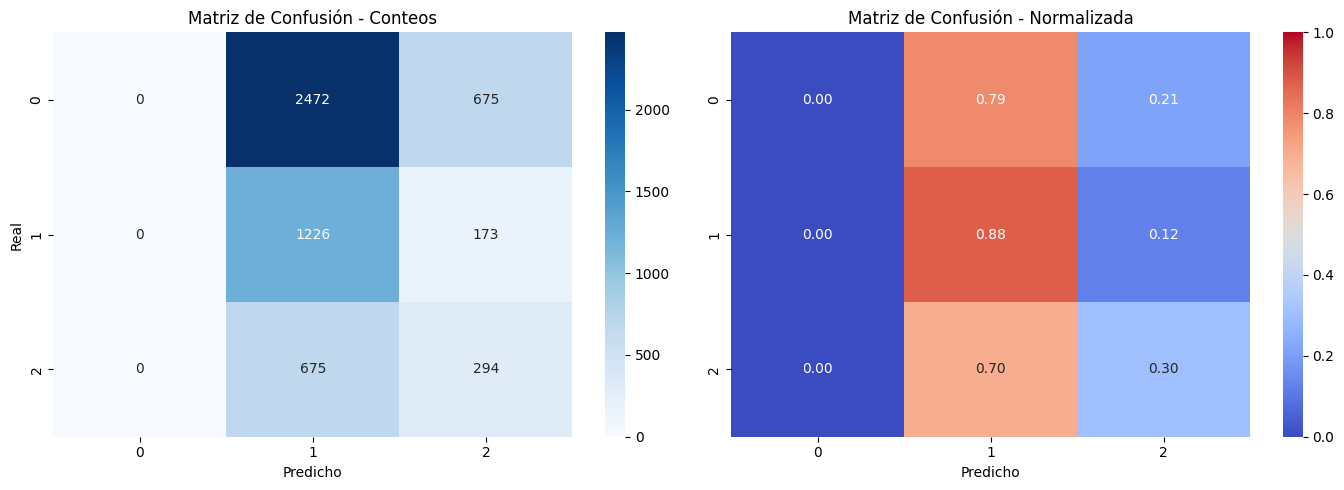


Distribución de clases reales:
Clase 0: 3147 muestras
Clase 1: 1399 muestras
Clase 2: 969 muestras

Distribución de predicciones:
Clase 1: 4373 predicciones
Clase 2: 1142 predicciones


In [32]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Verificar que el modelo existe
if "model" not in globals():
    raise RuntimeError("No se detectó la variable `model`. Carga el modelo primero.")

model.to(device)
model.eval()

# Obtener test_loader
test_loader = globals().get("test_loader")
if test_loader is None:
    raise RuntimeError("No se encontró `test_loader`.")

# Obtener pad_idx
pad_idx = globals().get("pad_idx", 0)
print(f"Pad idx: {pad_idx}")

# Inferencia
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        # Manejar el formato específico de tu collate_fn: (seqs, lengths, labels) o (seqs, lengths, labels, aux)
        if len(batch) >= 3:
            seqs, lengths, labels = batch[0], batch[1], batch[2]
            aux = batch[3] if len(batch) >= 4 else None
        else:
            print(f"Formato de batch inesperado: {len(batch)} elementos")
            continue

        # Mover a dispositivo
        seqs = seqs.to(device)
        lengths = lengths.to(device)
        labels = labels.to(device)
        if aux is not None:
            aux = aux.to(device)

        # Forward pass con lengths
        try:
            if aux is not None:
                outputs, _ = model(seqs, lengths, aux)
            else:
                outputs, _ = model(seqs, lengths, None)
        except Exception as e:
            print(f"Error en forward: {e}")
            continue

        # Obtener predicciones
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        labels_np = labels.cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels_np)

# Convertir a arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Verificar que tenemos datos
if len(all_preds) == 0:
    raise RuntimeError("No se obtuvieron predicciones. Revisa el formato de los datos.")

# Calcular número real de clases
num_classes = len(np.unique(np.concatenate([all_labels, all_preds])))
print(f"Número de clases detectadas: {num_classes}")
print(f"Total de muestras: {len(all_preds)}")

# Métricas básicas
acc = accuracy_score(all_labels, all_preds)
macrof1 = f1_score(all_labels, all_preds, average="macro")
print(f"\nAccuracy: {acc:.4f}")
print(f"Macro-F1: {macrof1:.4f}")

# Matriz de confusión
cm = confusion_matrix(all_labels, all_preds)
cm_norm = confusion_matrix(all_labels, all_preds, normalize='true')

# Visualizar matriz de confusión
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de conteos
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Matriz de Confusión - Conteos")
axes[0].set_xlabel("Predicho")
axes[0].set_ylabel("Real")

# Matriz normalizada
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='coolwarm', 
            ax=axes[1], vmin=0, vmax=1)
axes[1].set_title("Matriz de Confusión - Normalizada")
axes[1].set_xlabel("Predicho")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

# Mostrar distribución de clases
print("\nDistribución de clases reales:")
unique, counts = np.unique(all_labels, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"Clase {cls}: {count} muestras")

print("\nDistribución de predicciones:")
unique_pred, counts_pred = np.unique(all_preds, return_counts=True)
for cls, count in zip(unique_pred, counts_pred):
    print(f"Clase {cls}: {count} predicciones")

La matriz de confusión evidencia que la mayoría de las instancias fueron clasificadas como la segunda categoría, mientras que las demás presentan una escasa identificación correcta. Esto sugiere que, aunque el modelo logra aprender ciertos patrones generales, no discrimina adecuadamente entre las clases, probablemente debido al desbalance en los datos o a la similitud semántica entre categorías.


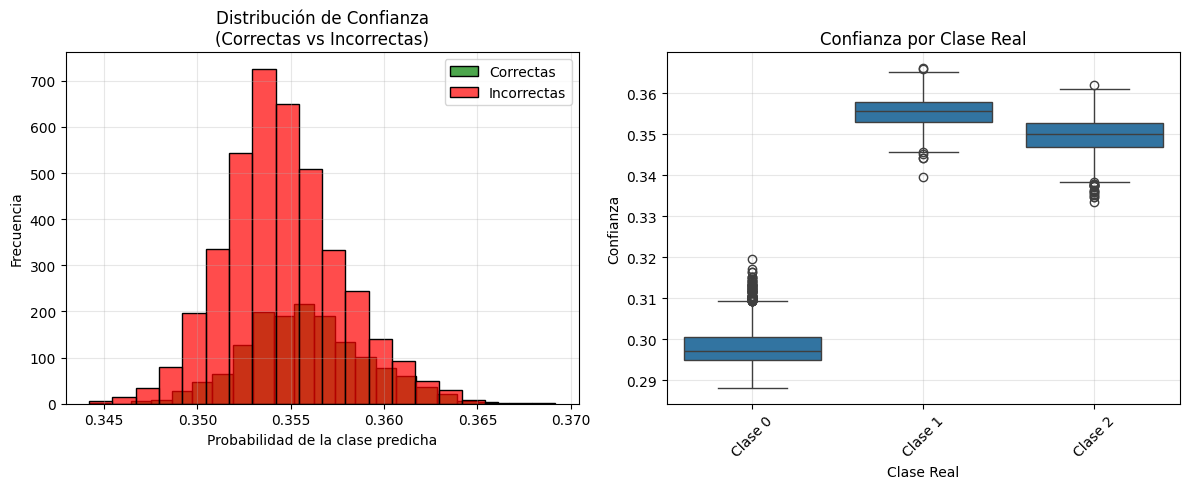

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score


all_probs = []
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        if len(batch) >= 3:
            seqs, lengths, labels = batch[0], batch[1], batch[2]
            aux = batch[3] if len(batch) >= 4 else None
            
            seqs = seqs.to(device)
            lengths = lengths.to(device)
            labels = labels.to(device)
            if aux is not None:
                aux = aux.to(device)

            if aux is not None:
                outputs, _ = model(seqs, lengths, aux)
            else:
                outputs, _ = model(seqs, lengths, None)
                
            # Obtener probabilidades
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)
            
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
correct_mask = (all_preds == all_labels)
max_probs = np.max(all_probs, axis=1)

sns.histplot(data=max_probs[correct_mask], label='Correctas', alpha=0.7, bins=20, color='green')
sns.histplot(data=max_probs[~correct_mask], label='Incorrectas', alpha=0.7, bins=20, color='red')
plt.xlabel('Probabilidad de la clase predicha')
plt.ylabel('Frecuencia')
plt.title('Distribución de Confianza\n(Correctas vs Incorrectas)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
class_confidences = []
class_labels = []
unique_labels = np.unique(all_labels)

for cls in unique_labels:
    mask = (all_labels == cls)
    if np.sum(mask) > 0:

        correct_class_probs = all_probs[mask, cls]
        class_confidences.extend(correct_class_probs)
        class_labels.extend([f'Clase {cls}'] * len(correct_class_probs))

import pandas as pd
conf_df = pd.DataFrame({
    'Confianza': class_confidences,
    'Clase Real': class_labels
})

sns.boxplot(data=conf_df, x='Clase Real', y='Confianza')
plt.xticks(rotation=45)
plt.title('Confianza por Clase Real')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

La distribución de confianza muestra que el modelo predice con niveles muy similares de probabilidad tanto en aciertos como en errores, lo que indica *baja calibración* y falta de certeza real en sus decisiones. El histograma evidencia un rango estrecho de probabilidades centrado alrededor de 0.35, señal de que el modelo evita tomar decisiones con alta seguridad. En el gráfico por clase, se observa que la *clase 1* concentra las predicciones más confiadas, mientras que la *clase 0* presenta la menor confianza promedio, lo que coincide con su bajo rendimiento en la matriz de confusión. En conjunto, estos resultados sugieren que el modelo tiende a sobreestimar la clase dominante y no logra discriminar con claridad entre categorías, reflejando una necesidad de mejor calibración o ajuste de balance de clases.


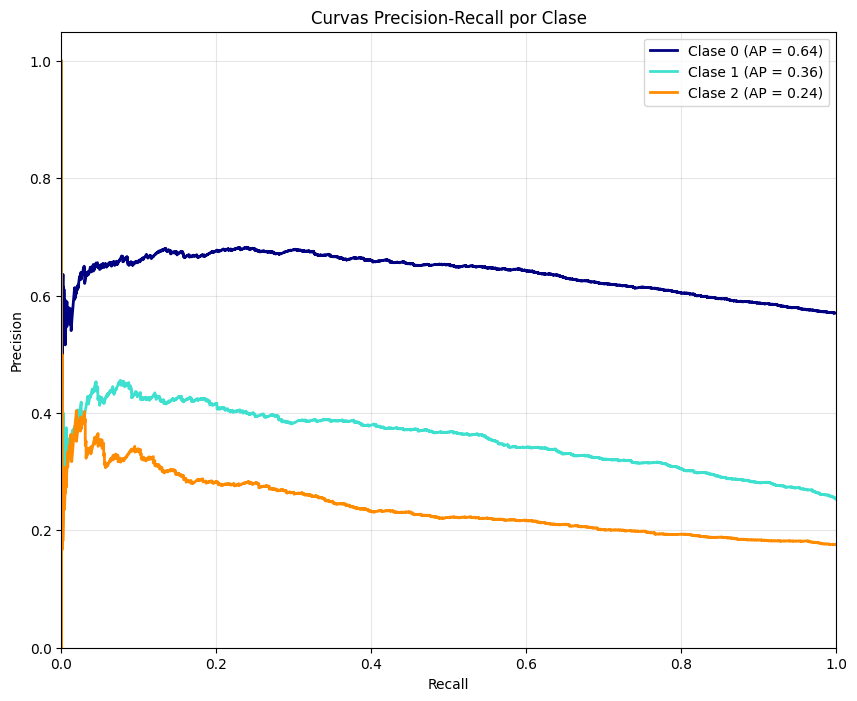

In [34]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from itertools import cycle

# Precisión-Recall por clase
plt.figure(figsize=(10, 8))

# Para problemas multiclase, usar One-vs-Rest
from sklearn.preprocessing import label_binarize

# Binarizar las etiquetas
y_true_bin = label_binarize(all_labels, classes=range(num_classes))
y_score = all_probs

# Para cada clase
colors = cycle(['navy', 'turquoise', 'darkorange', 'cornflowerblue', 'teal'])
for i, color in zip(range(num_classes), colors):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_score[:, i])
    avg_precision = average_precision_score(y_true_bin[:, i], y_score[:, i])
    
    plt.plot(recall, precision, color=color, lw=2,
             label=f'Clase {i} (AP = {avg_precision:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Curvas Precision-Recall por Clase')
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.show()

Las curvas  muestran un rendimiento desigual entre clases: la *clase 0* alcanza un área promedio (AP) de *0.64*, indicando una mejor capacidad de identificar ejemplos positivos con baja tasa de falsos positivos, mientras que las clases 1 y 2 obtienen valores de *0.36* y**0.24*, respectivamente, reflejando una precisión y cobertura más limitadas. La caída pronunciada de las curvas de estas últimas sugiere que el modelo pierde consistencia al aumentar el *recall*, evidenciando dificultad para mantener precisión en contextos de alta sensibilidad.
